# DSN Preprocessing — Daily RMS and Phase Scintillation

This notebook combines the large-scale Doppler RMS diagnostics and the phase scintillation preprocessing pipeline into a single workflow.

---

## Workflow

### SECTION 1 — Daily Doppler RMS Diagnostics

1. Load DSN Doppler data
2. Apply quality filtering
3. Compute daily Doppler RMS
4. Merge with solar elongation (SEP)
5. Compare against DSN solar scintillation model
6. Add seasonal tropospheric model
7. Generate large-scale diagnostic plots

---

### SECTION 2 — Phase Scintillation Window Construction

This notebook converts Doppler residuals into phase fluctuations and computes band-limited phase scintillation using a spectral (PSD-based) method.

---

## Method

The processing steps are:

1. Load filtered Doppler data
2. Convert Doppler frequency → phase:
   
   φ(t) = 2π ∫ f(t) dt

3. Segment data into overlapping time windows:
   - window length: 20 minutes
   - step size: 10 minutes

4. For each window:
   - compute power spectral density (Welch method)
   - integrate PSD over the scintillation band:
     
     3×10⁻⁴ Hz to 3×10⁻² Hz

5. Compute band-limited phase RMS for each window

---

## Output

This notebook produces:

- `phase_windows_<year>.csv`

Each row represents a time window with:

- phase RMS (rad)
- number of samples
- window timing

This dataset is the core input for CIR and CME detection.
---

## Outputs

This notebook produces:

- `daily_metrics_<year>.csv`
- `phase_windows_<year>.csv`

These outputs form the input to the CIR and CME detection pipeline.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.settings_2010 import *

deBug = True
sav_file = True

from src.io_utils import (
    load_dsn_data,
    load_horizons_daily_sep,
)

from src.doppler_utils import (
    prepare_daily_rms_table,
    print_daily_summary,
    add_seasonal_troposphere_model,
)

from src.phase_utils import (
    compute_phase_rms_windows,
    print_phase_summary,
)

from src.plot_utils import (
    plot_daily_rms_vs_sep,
    plot_phase_scintillation_time_series,
)

debug= True
save_file = True

# SECTION 1 — Daily Doppler RMS Diagnostics

In [2]:
horizons_daily = load_horizons_daily_sep(HORIZONS_FILE)

df = load_dsn_data(
    DOPPLER_FILE,
    valid_only=USE_VALID_FLAG,
    min_elev_deg=MIN_ELEV_DEG,
    max_abs_doppler_hz=MAX_ABS_DOPPLER_HZ,
)

if debug:

    print("Horizons rows:", len(horizons_daily))
    print(
        "Horizons range:",
        horizons_daily["day"].min(),
        "→",
        horizons_daily["day"].max(),
    )

    print("DSN rows:", len(df))
    print(
        "DSN range:",
        df["UTC_time"].min(),
        "→",
        df["UTC_time"].max(),
    )

Horizons rows: 365
Horizons range: 2010-01-01 00:00:00 → 2010-12-31 00:00:00
DSN rows: 867761
DSN range: 2010-01-01 09:37:22.814000 → 2010-12-30 12:39:54.533000


In [3]:
daily_df = prepare_daily_rms_table(
    dsn_df=df,
    horizons_daily=horizons_daily,
    f_carrier_hz=F_CARRIER,
    c_mps=C,
    T_int_sec=T_INT,
    C_band=C_BAND,
    resample_rule=RESAMPLE_RULE,
    min_samples_per_day=MIN_SAMPLES_PER_DAY,
    smooth_days=SMOOTH_DAYS,
    add_tropo_diagnostic=False,
)

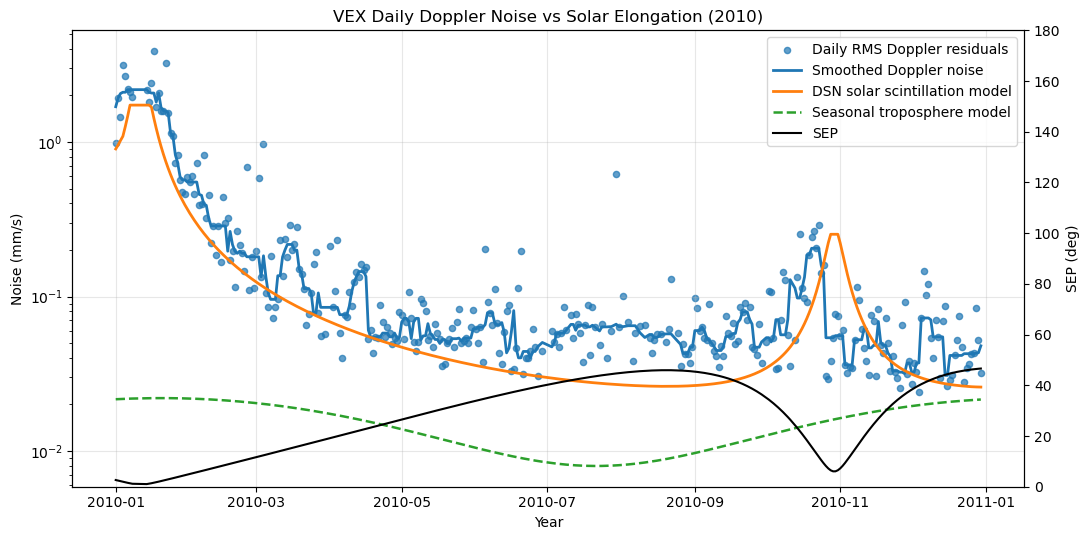

In [4]:
daily_df = add_seasonal_troposphere_model(
    daily_df=daily_df,
    amplitude_mm_s=TROPO_AMP,
    offset_mm_s=TROPO_OFFSET,
    phase_day=TROPO_PHASE_DAY,
    smooth_days=SMOOTH_DAYS,
)

fig, axes = plot_daily_rms_vs_sep(
    daily_df=daily_df,
    year=YEAR,
)

plt.show()

In [5]:
if save_file:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    daily_csv = (
        OUTPUT_DIR
        / f"daily_metrics_{YEAR}.csv"
    )

    daily_df.to_csv(
        daily_csv,
        index=False,
    )

    print("Saved:", daily_csv)

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/daily_metrics_2010.csv


In [6]:
if debug:

    print(daily_df.columns.tolist())

    display(daily_df.tail())

['day', 'doppler_rms_mm_s', 'n_60s_samples', 'elongation_deg', 'solar_model_mm_s', 'decimal_year', 'doppler_smooth_mm_s', 'solar_smooth_mm_s', 'doy', 'tropo_seasonal_mm_s', 'tropo_seasonal_smooth_mm_s']


,day,doppler_rms_mm_s,n_60s_samples,elongation_deg,solar_model_mm_s,decimal_year,doppler_smooth_mm_s,solar_smooth_mm_s,doy,tropo_seasonal_mm_s,tropo_seasonal_smooth_mm_s
331,2010-12-26,0.042642,438,46.2207,0.026071,2010.982888,0.042642,0.026071,360,0.036434,0.036434
332,2010-12-27,0.043255,435,46.3342,0.026011,2010.985626,0.042642,0.026011,361,0.036628,0.036628
333,2010-12-28,0.084529,433,46.4369,0.025957,2010.988364,0.042948,0.025984,362,0.036817,0.036722
334,2010-12-29,0.052680,431,46.5293,0.025908,2010.991102,0.043255,0.025957,363,0.037000,0.036817
335,2010-12-30,0.031980,97,46.6116,0.025865,2010.993840,0.047967,0.025932,364,0.037179,0.036908


# SECTION 2 — Phase Scintillation Window Construction

In [12]:
# ============================================================
# SECTION 2 — Phase scintillation windows
# Full validation run: compute from scratch once
# ============================================================

print("Computing phase windows from scratch...")

windows_df = compute_phase_rms_windows(
    df,
    time_col="UTC_time",
    doppler_col="doppler",
    dt_target_sec=DT_TARGET,
    window_min=WINDOW_MIN,
    step_min=STEP_MIN,
    min_samples=MIN_SAMPLES,
    f_low_hz=F_LOW,
    f_high_hz=F_HIGH,
)

print("Phase windows computed:", len(windows_df))

# ------------------------------------------------------------
# Add elongation to each phase window
# ------------------------------------------------------------

geom = horizons_daily.set_index("day").sort_index()

windows_df["elongation_deg"] = np.interp(
    windows_df["mid"].astype("int64"),
    geom.index.astype("int64"),
    geom["elongation_deg"],
)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

if deBug:
    print_phase_summary(windows_df)

    print("Columns:")
    print(windows_df.columns.tolist())

    display(windows_df.head())
    display(windows_df.tail())



Computing phase windows from scratch...
Phase windows computed: 14590
Windows created: 14590
Window time range: 2010-01-01 09:37:20 → 2010-12-30 12:37:20
Phase RMS range (rad): 0.04816102296569241 → 63.824174239744025
Columns:
['start', 'end', 'mid', 'phase_rms_rad', 'n_samples', 'elongation_deg']


,start,end,mid,phase_rms_rad,n_samples,elongation_deg
0,2010-01-01 09:37:20,2010-01-01 09:57:20,2010-01-01 09:47:20,14.885682,120,2.547583
1,2010-01-01 09:47:20,2010-01-01 10:07:20,2010-01-01 09:57:20,15.971841,120,2.545998
2,2010-01-01 09:57:20,2010-01-01 10:17:20,2010-01-01 10:07:20,8.508995,120,2.544412
3,2010-01-01 10:07:20,2010-01-01 10:27:20,2010-01-01 10:17:20,6.813039,120,2.542827
4,2010-01-01 10:17:20,2010-01-01 10:37:20,2010-01-01 10:27:20,9.688446,120,2.541242


,start,end,mid,phase_rms_rad,n_samples,elongation_deg
14585,2010-12-30 11:37:20,2010-12-30 11:57:20,2010-12-30 11:47:20,0.314302,120,46.647409
14586,2010-12-30 11:47:20,2010-12-30 12:07:20,2010-12-30 11:57:20,0.442294,120,46.647915
14587,2010-12-30 11:57:20,2010-12-30 12:17:20,2010-12-30 12:07:20,0.494766,120,46.648421
14588,2010-12-30 12:07:20,2010-12-30 12:27:20,2010-12-30 12:17:20,0.546487,120,46.648927
14589,2010-12-30 12:17:20,2010-12-30 12:37:20,2010-12-30 12:27:20,0.404686,120,46.649434


In [7]:
phase_csv = OUTPUT_DIR / f"phase_windows_{YEAR}.csv"

if phase_csv.exists():

    print("Loading cached phase windows:", phase_csv)

    windows_df = pd.read_csv(phase_csv)

    for col in ["start", "end", "mid"]:
        windows_df[col] = pd.to_datetime(windows_df[col])

else:

    print("Computing phase windows...")

    windows_df = compute_phase_rms_windows(
        df,
        time_col="UTC_time",
        doppler_col="doppler",
        dt_target_sec=DT_TARGET,
        window_min=WINDOW_MIN,
        step_min=STEP_MIN,
        min_samples=MIN_SAMPLES,
        f_low_hz=F_LOW,
        f_high_hz=F_HIGH,
    )

    geom = horizons_daily.set_index("day")

    windows_df["elongation_deg"] = np.interp(
        windows_df["mid"].astype("int64"),
        geom.index.astype("int64"),
        geom["elongation_deg"],
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    windows_df.to_csv(phase_csv, index=False)

    print("Saved:", phase_csv)

if deBug:
    print_phase_summary(windows_df)
    display(windows_df.head())
    print(windows_df.columns.tolist())
    display(windows_df.tail())

Loading cached phase windows: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/phase_windows_2010.csv
Windows created: 14590
Window time range: 2010-01-01 09:37:20 → 2010-12-30 12:37:20
Phase RMS range (rad): 0.0481610229656924 → 63.824174239744025


,start,end,mid,phase_rms_rad,n_samples
0,2010-01-01 09:37:20,2010-01-01 09:57:20,2010-01-01 09:47:20,14.885682,120
1,2010-01-01 09:47:20,2010-01-01 10:07:20,2010-01-01 09:57:20,15.971841,120
2,2010-01-01 09:57:20,2010-01-01 10:17:20,2010-01-01 10:07:20,8.508995,120
3,2010-01-01 10:07:20,2010-01-01 10:27:20,2010-01-01 10:17:20,6.813039,120
4,2010-01-01 10:17:20,2010-01-01 10:37:20,2010-01-01 10:27:20,9.688446,120


['start', 'end', 'mid', 'phase_rms_rad', 'n_samples']


,start,end,mid,phase_rms_rad,n_samples
14585,2010-12-30 11:37:20,2010-12-30 11:57:20,2010-12-30 11:47:20,0.314302,120
14586,2010-12-30 11:47:20,2010-12-30 12:07:20,2010-12-30 11:57:20,0.442294,120
14587,2010-12-30 11:57:20,2010-12-30 12:17:20,2010-12-30 12:07:20,0.494766,120
14588,2010-12-30 12:07:20,2010-12-30 12:27:20,2010-12-30 12:17:20,0.546487,120
14589,2010-12-30 12:17:20,2010-12-30 12:37:20,2010-12-30 12:27:20,0.404686,120


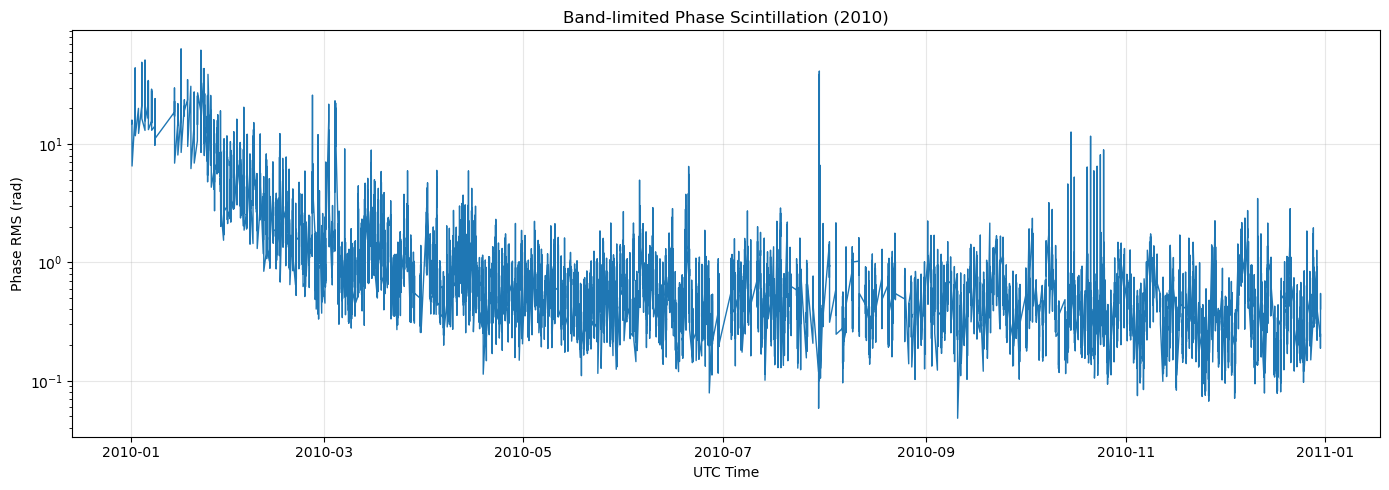

In [10]:
fig, ax = plot_phase_scintillation_time_series(windows_df, year=YEAR)
plt.show()

In [8]:
if debug:

    valid = windows_df["phase_rms_rad"].dropna()

    print("Number of windows:", len(windows_df))

    print("Phase RMS min:", valid.min())

    print("Phase RMS median:", valid.median())

    print("Phase RMS max:", valid.max())

    print(
        "Median samples per window:",
        windows_df["n_samples"].median(),
    )

Number of windows: 14590
Phase RMS min: 0.0481610229656924
Phase RMS median: 0.573514743962771
Phase RMS max: 63.824174239744025
Median samples per window: 120.0


In [9]:
if save_file:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    phase_csv = (
        OUTPUT_DIR
        / f"phase_windows_{YEAR}.csv"
    )

    fig_path = (
        OUTPUT_DIR
        / f"phase_scintillation_{YEAR}.png"
    )

    windows_df.to_csv(
        phase_csv,
        index=False,
    )

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight",
    )

    print("Saved:", phase_csv)
    print("Saved:", fig_path)



Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/phase_windows_2010.csv
Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/phase_scintillation_2010.png
